In [1]:
from cartopy.io.shapereader import Reader
from cartopy.feature import ShapelyFeature
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import numpy as np
import pyart
from netCDF4 import Dataset
from metpy.units import units
from metpy.calc import dewpoint_from_specific_humidity, relative_humidity_from_specific_humidity, wind_speed, temperature_from_potential_temperature
from datetime import datetime, timedelta
from wrf import getvar


## You are using the Python ARM Radar Toolkit (Py-ART), an open source
## library for working with weather radar data. Py-ART is partly
## supported by the U.S. Department of Energy as part of the Atmospheric
## Radiation Measurement (ARM) Climate Research Facility, an Office of
## Science user facility.
##
## If you use this software to prepare a publication, please cite:
##
##     JJ Helmus and SM Collis, JORS 2016, doi: 10.5334/jors.119



In [2]:
#dt = datetime(2021,6,4,10)
#dt = datetime(2022,7,19,10)
dt = datetime(2022,9,15,3)

In [3]:
#wrfout = Dataset('/glade/scratch/mawilson/20210604_newcase/scripts/test/wrfrun/fc_OldThompson/2021060318.e002/wrfout_d01_2021-'+str(dt.isoformat()[5:7])+'-'+str(dt.isoformat()[8:10])+'_'+str(dt.isoformat()[11:13])+':00:00')
#wrfout = Dataset('/glade/scratch/mawilson/20210604_newcase/scripts/test/wrfrun/fc_ThompsonAerosol/2021060318.e001/wrfout_d01_2021-'+str(dt.isoformat()[5:7])+'-'+str(dt.isoformat()[8:10])+'_'+str(dt.isoformat()[11:13])+':00:00')
#wrfout = Dataset('/glade/scratch/mawilson/20210604_newcase/scripts/test/wrfrun/fc_'+exper+'/2021060400.e0'+str(mem)+'/wrfout_d01_2021-'+str(dt.isoformat()[5:7])+'-'+str(dt.isoformat()[8:10])+'_'+str(dt.isoformat()[11:13])+':00:00')
#wrfout = Dataset('/glade/scratch/mawilson/20210604_newcase/scripts/test/wrfrun/fc_'+exper+'/2022071900.e0'+str(mem)+'/wrfout_d01_2022-'+str(dt.isoformat()[5:7])+'-'+str(dt.isoformat()[8:10])+'_'+str(dt.isoformat()[11:13])+':00:00')
#wrfout = Dataset('/glade/derecho/scratch/mawilson/20210604_newcase/nature100_test/wrfout_d02_2021-'+str(dt.isoformat()[5:7])+'-'+str(dt.isoformat()[8:10])+'_'+str(dt.isoformat()[11:13])+':00:00')
#wrfout = Dataset('/glade/derecho/scratch/mawilson/20210604_newcase/nature_100IOP6/newland_spinup/wrfout_d02_2022-'+str(dt.isoformat()[5:7])+'-'+str(dt.isoformat()[8:10])+'_'+str(dt.isoformat()[11:13])+':00:00')
#wrfout = Dataset('/glade/derecho/scratch/mawilson/20210604_newcase/nature_100IOP6/mem8_ens1/wrfout_d02_2022-'+str(dt.isoformat()[5:7])+'-'+str(dt.isoformat()[8:10])+'_'+str(dt.isoformat()[11:13])+':00:00')
#wrfout = Dataset('/glade/derecho/scratch/mawilson/20210604_newcase/nature_100IOP4/param_sfc_MYNN_new/wrfout_d02_2022-'+str(dt.isoformat()[5:7])+'-'+str(dt.isoformat()[8:10])+'_'+str(dt.isoformat()[11:13])+':00:00')
#wrfout = Dataset('/glade/derecho/scratch/mawilson/OSSE_WRF/ic_wrf/wrfout_test1/wrfout_d01_2022-'+str(dt.isoformat()[5:7])+'-'+str(dt.isoformat()[8:10])+'_'+str(dt.isoformat()[11:13])+':00:00')
wrfout = Dataset('/glade/derecho/scratch/mawilson/OSSE_WRF/ic_wrf/wrfout_test1/wrfout_d01_2022-'+str(dt.isoformat()[5:7])+'-'+str(dt.isoformat()[8:10])+'_'+str(dt.isoformat()[11:13])+':00:00')

#wrfout = Dataset('/glade/scratch/mawilson/20210604_newcase/scripts/test/wrfrun/fc/2021060400.e040/wrfout_d01_2021-'+str(dt.isoformat()[5:7])+'-'+str(dt.isoformat()[8:10])+'_'+str(dt.isoformat()[11:13])+':00:00')

In [4]:
lon = wrfout.variables['XLONG']
lat = wrfout.variables['XLAT']
U10 = wrfout.variables['U10']
V10 = wrfout.variables['U10']
T2 = np.asarray(wrfout.variables['T2'])*units('K')
T2F = T2 .to('degF')
Q2 = np.asarray(wrfout.variables['Q2'])
P2 = np.asarray(wrfout.variables['PSFC'][:]/100) * units('hPa')
Td2 = dewpoint_from_specific_humidity(P2[0,:,:], T2[0,:,:], Q2[0,:,:]*units('kg/kg'))
RH2 = relative_humidity_from_specific_humidity(P2[0,:,:], T2[0,:,:], Q2[0,:,:]*units('kg/kg'))
SPD10 = wind_speed(np.asarray(U10)*units('m/s'), np.asarray(V10)*units('m/s'))
cloud=wrfout.variables['QCLOUD']
#Get fluxes
LH1 = wrfout.variables['LH'][:]
HF1 = wrfout.variables['HFX'][:]

In [5]:
print(np.max(lon), np.min(lon), np.max(lat), np.min(lat))

-80.64637 -88.373634 42.034187 36.038418


In [6]:
#Load in observations
ObsFile = np.genfromtxt('SavedObs'+dt.isoformat()[0:10]+dt.isoformat()[11:13]+'.csv',delimiter=',', skip_header=1)
ObsFileStr = np.genfromtxt('SavedObs'+dt.isoformat()[0:10]+dt.isoformat()[11:13]+'.csv',delimiter=',', 
                           skip_header=1,usecols=(0),dtype='str')
Obs_Ti = ObsFile[:,1]
Obs_R2i = ObsFile[:,5]
Obs_Si = ObsFile[:,6]
Obs_lon = ObsFile[:,8]
Obs_lat = ObsFile[:,9]
Obs_V = ObsFile[:,11]

In [7]:
#Make a map to show the domain
lati = 37.15
loni = -84.00

# lat = 39.4
# lon = -101.80
cenlat1 = float(lati)
cenlon1 = float(loni)

# LL1 = (cenlon1-10.,cenlat1-4.0,ccrs.PlateCarree())
# UR1 = (cenlon1+6.,cenlat1+8.0,ccrs.PlateCarree())

# #Set up our map projection

crs = ccrs.LambertConformal(central_longitude=-100.0, central_latitude=45.0)

#Read in files for state and county boundaries
fname = 'cb_2016_us_county_20m/cb_2016_us_county_20m.shp'
fname2 = 'cb_2016_us_state_20m/cb_2016_us_state_20m.shp'
counties = ShapelyFeature(Reader(fname).geometries(),ccrs.PlateCarree(), facecolor = 'none', edgecolor = 'black')
states = ShapelyFeature(Reader(fname2).geometries(),ccrs.PlateCarree(), facecolor = 'none', edgecolor = 'black')

start
plotted
A
B
C


/glade/derecho/scratch/mawilson/tmp/ipykernel_73197/1131251975.py:60: RuntimeWarning: All-NaN slice encountered
  cb = axes['D'].pcolormesh(lon[0,:,:], lat[0,:,:], np.nanmax(cloud1[0,0:3,:,:],axis=0), cmap=plt.cm.binary, vmin=0.001, vmax=0.1, transform=ccrs.PlateCarree(),zorder=1)


Text(0.59, 0.98, '3 km WRF Forecast  \n2022-09-15 03:00 UTC')

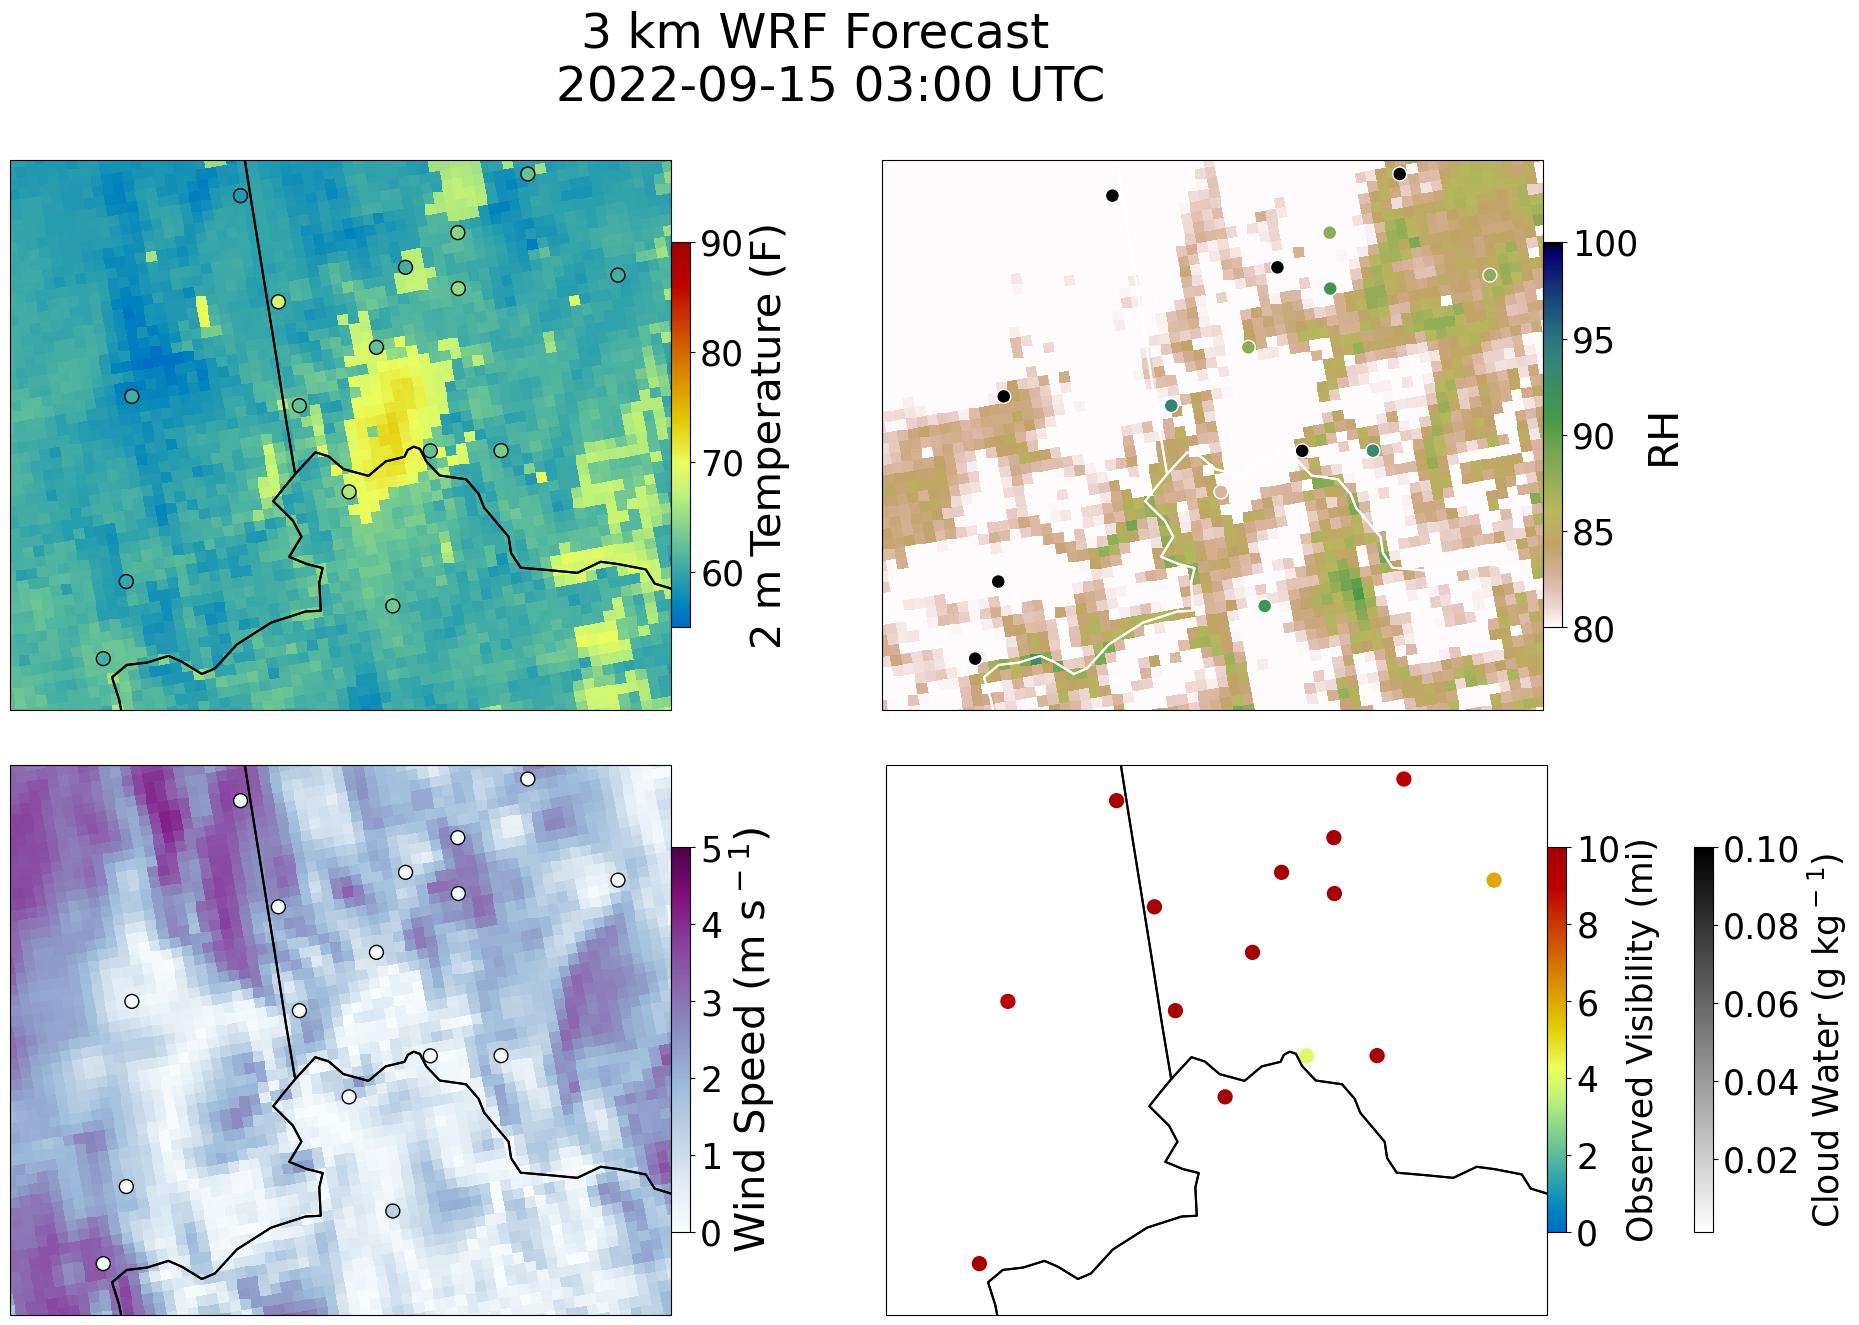

In [8]:
cenlon2 = cenlon1+0.2
cenlat2 = cenlat1+1.5

LL2 = (cenlon2-1.75,cenlat2+0.0,ccrs.PlateCarree())
UR2 = (cenlon2+0.,cenlat2+1.05,ccrs.PlateCarree())

figure_mosaic = """
AB
CD
"""

fig, axes = plt.subplot_mosaic(mosaic=figure_mosaic, figsize=(30,15), subplot_kw={'projection': crs})

print('start')
ctlev = np.arange(30,100,5)
#axes['A'].coastlines('50m',edgecolor='black',linewidth=0.75)
axes['A'].set_extent([LL2[0],UR2[0],LL2[1],UR2[1]])
axes['A'].add_feature(states,edgecolor='black',linewidth=1.5)
#axes['A'].add_feature(counties, edgecolor = 'black', linewidth = 0.5)
cf = axes['A'].pcolormesh(lon[0,:,:], lat[0,:,:], T2F[0,:,:], cmap=pyart.graph.cm_colorblind.HomeyerRainbow, vmin=55, vmax=90, transform=ccrs.PlateCarree())
print('plotted')
cg = plt.colorbar(cf, ax = axes['A'], shrink = .7, pad = 0)
cg.ax.tick_params(labelsize=25)
cg.set_label("2 m Temperature (F)",size = 30)
axes['A'].scatter(Obs_lon, Obs_lat, c=Obs_Ti, edgecolors='k', s=100, vmin=55, vmax=90, cmap=pyart.graph.cm_colorblind.HomeyerRainbow, transform=ccrs.PlateCarree())
print('A')

#axes['B'].coastlines('50m',edgecolor='white',linewidth=0.75)
axes['B'].set_extent([LL2[0],UR2[0],LL2[1],UR2[1]])
axes['B'].add_feature(states,edgecolor='white',linewidth=1.5)
#axes['A'].add_feature(counties, edgecolor = 'black', linewidth = 0.5)
cb = axes['B'].pcolormesh(lon[0,:,:], lat[0,:,:], RH2*100, cmap=plt.cm.gist_earth_r, vmin=80, vmax=100, transform=ccrs.PlateCarree())
cg = plt.colorbar(cb, ax = axes['B'], shrink = .7, pad = 0)
cg.ax.tick_params(labelsize=25)
cg.set_label("RH",size = 30)
axes['B'].scatter(Obs_lon, Obs_lat, c=Obs_R2i*100, edgecolors='white', s=100, cmap=plt.cm.gist_earth_r, vmin=80, vmax=100, transform=ccrs.PlateCarree())
print('B')

prslev = np.arange(984,1060,4)
#axes['C'].coastlines('50m',edgecolor='black',linewidth=0.75)
axes['C'].set_extent([LL2[0],UR2[0],LL2[1],UR2[1]])
axes['C'].add_feature(states,edgecolor='black',linewidth=1.5)
#axes['A'].add_feature(counties, edgecolor = 'black', linewidth = 0.5)
#axes['C'].contour(ds4.longitude, ds4.latitude, pres/100,prslev,colors='k', linewidths=3, transform=ccrs.PlateCarree())
cb = axes['C'].pcolormesh(lon[0,:,:], lat[0,:,:], SPD10[0,:,:], cmap=plt.cm.BuPu, vmin=0, vmax=5, transform=ccrs.PlateCarree())
cg = plt.colorbar(cb, ax = axes['C'], shrink = .7, pad = 0)
cg.ax.tick_params(labelsize=25)
cg.set_label("Wind Speed (m s$^-$$^1$)",size = 30)
axes['C'].scatter(Obs_lon, Obs_lat, c=Obs_Si, edgecolors='k', s=100, cmap=plt.cm.BuPu, vmin=0, vmax=5, transform=ccrs.PlateCarree())
print('C')

prslev = [0,0.25,0.5,1.0,2.0,3.0,6.0]
#axes['D'].coastlines('50m',edgecolor='white',linewidth=0.75)
axes['D'].set_extent([LL2[0],UR2[0],LL2[1],UR2[1]])
axes['D'].add_feature(states,edgecolor='k',linewidth=1.5,zorder=4)
#axes['A'].add_feature(counties, edgecolor = 'black', linewidth = 0.5)
cloud1 = np.copy(np.asarray(cloud))*1000
cloud1[cloud1<0.001] = np.nan
#axes['C'].contour(ds4.longitude, ds4.latitude, pres/100,prslev,colors='k', linewidths=3, transform=ccrs.PlateCarree())
cb = axes['D'].pcolormesh(lon[0,:,:], lat[0,:,:], np.nanmax(cloud1[0,0:3,:,:],axis=0), cmap=plt.cm.binary, vmin=0.001, vmax=0.1, transform=ccrs.PlateCarree(),zorder=1)
cg = plt.colorbar(cb, ax = axes['D'], shrink = .7, pad = 0.06, fraction=0.046)
cg.ax.tick_params(labelsize=25)
cg.set_label("Cloud Water (g kg$^-$$^1$)",size = 25)
cn=axes['D'].scatter(Obs_lon, Obs_lat, c=Obs_V, s=100, cmap=pyart.graph.cm_colorblind.HomeyerRainbow, vmin=0, vmax=10, transform=ccrs.PlateCarree())
cb = plt.colorbar(cn, ax = axes['D'], shrink = .7, pad = 0.00,fraction=0.046)
cb.ax.tick_params(labelsize=25)
cb.set_label("Observed Visibility (mi)",size = 25)

plt.subplots_adjust(wspace=-0.4, hspace=0.1)
fig.patch.set_facecolor('white')
plt.suptitle('3 km WRF Forecast  \n'+dt.isoformat()[0:10]+' '+dt.isoformat()[11:16]+' UTC', size=35, x=.59)

#plt.savefig('Member16_Nature100map'+dt.isoformat()[0:10]+dt.isoformat()[11:16]+'.png', bbox_inches='tight')

start
plotted
A
B
C


/glade/derecho/scratch/mawilson/tmp/ipykernel_73197/3580268781.py:60: RuntimeWarning: All-NaN slice encountered
  cb = axes['D'].pcolormesh(lon[0,:,:], lat[0,:,:], np.nanmax(cloud1[0,0:3,:,:],axis=0), cmap=plt.cm.binary, vmin=0.001, vmax=0.1, transform=ccrs.PlateCarree(),zorder=1)


Text(0.59, 0.98, '3 km WRF Forecast  \n2022-09-15 03:00 UTC')

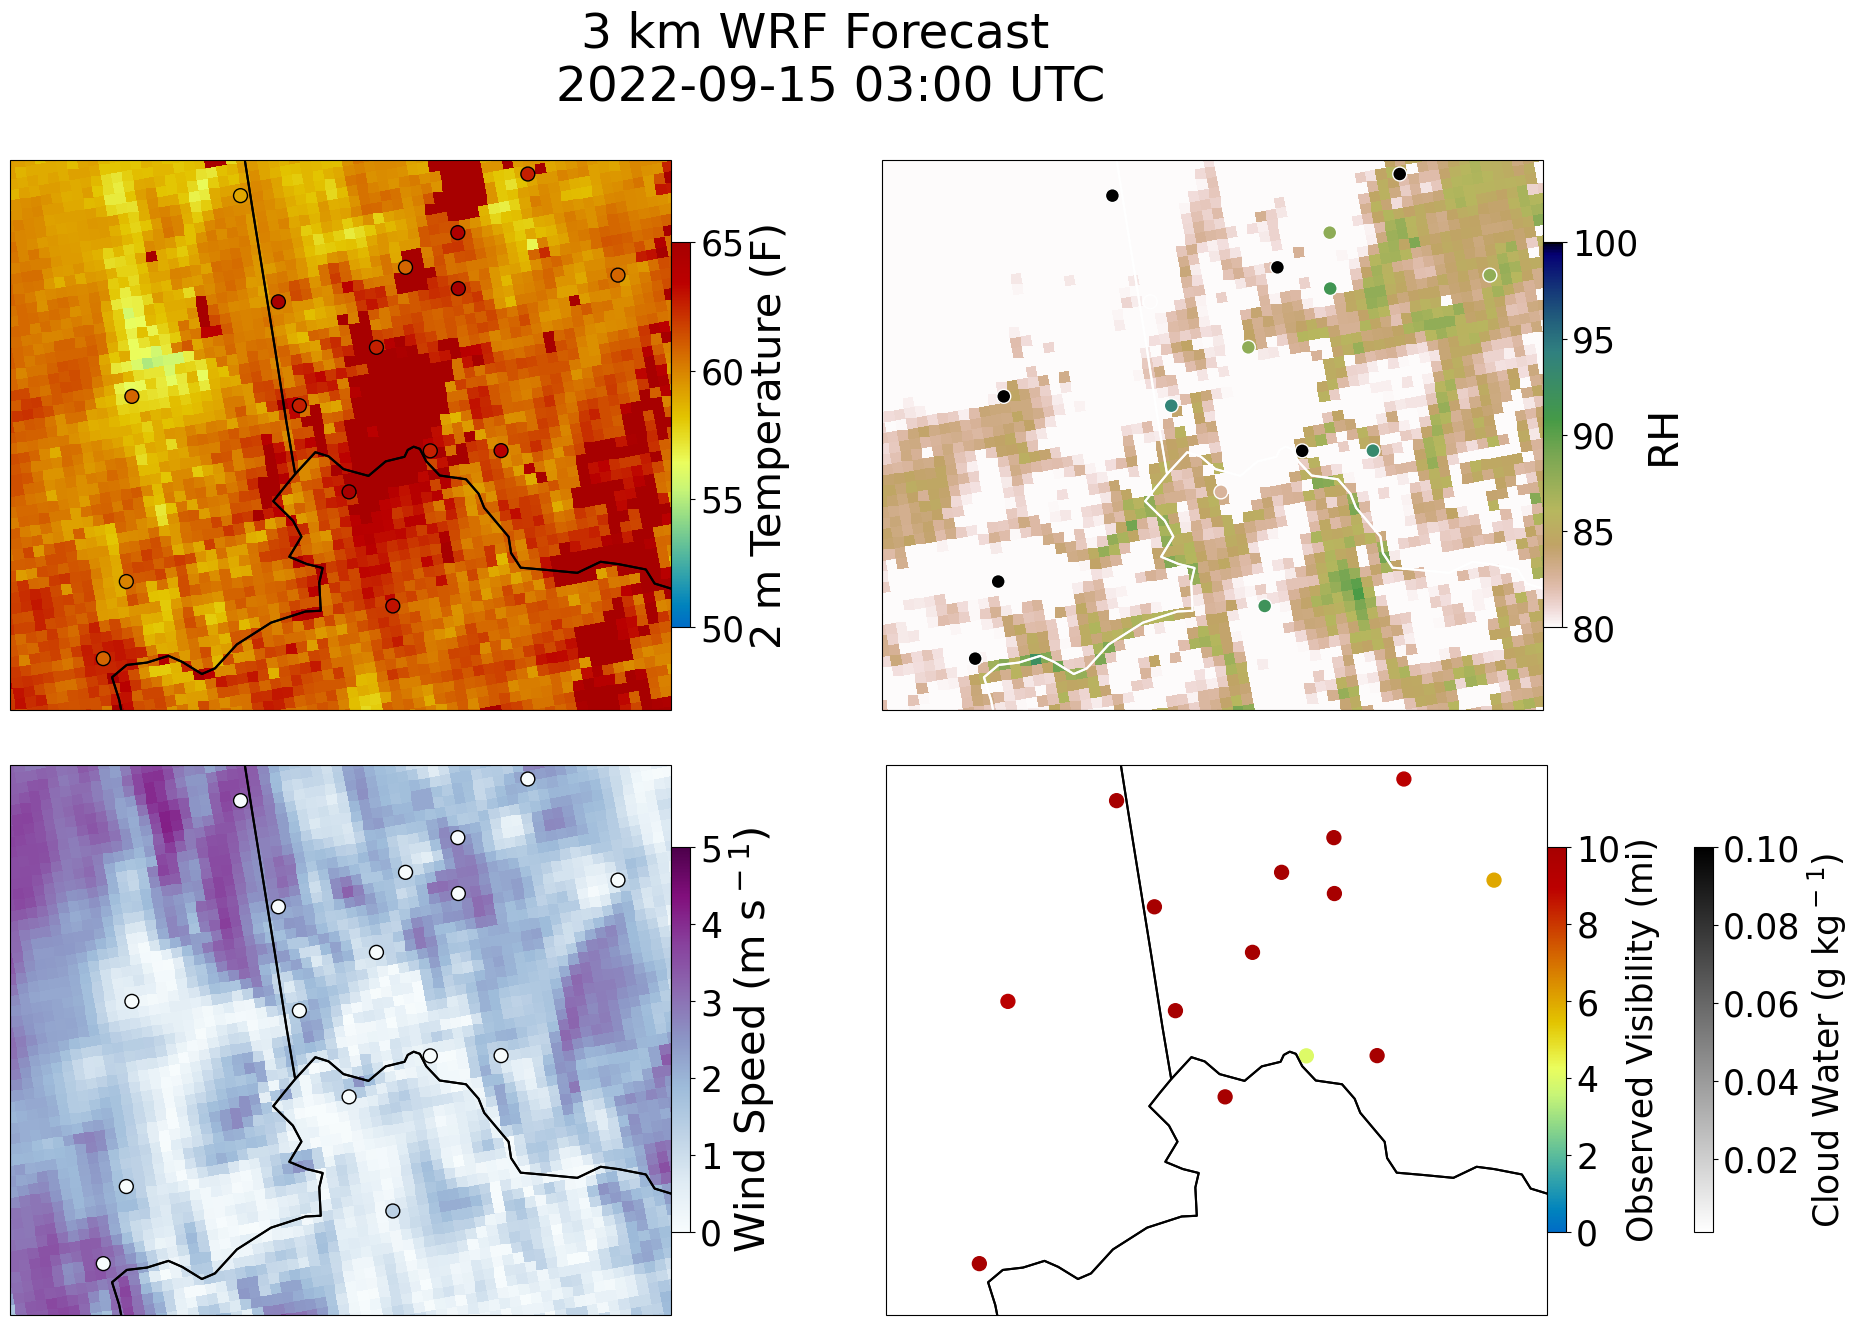

In [9]:
cenlon2 = cenlon1+0.2
cenlat2 = cenlat1+1.5

LL2 = (cenlon2-1.75,cenlat2+0.0,ccrs.PlateCarree())
UR2 = (cenlon2+0.,cenlat2+1.05,ccrs.PlateCarree())

figure_mosaic = """
AB
CD
"""

fig, axes = plt.subplot_mosaic(mosaic=figure_mosaic, figsize=(30,15), subplot_kw={'projection': crs})

print('start')
ctlev = np.arange(30,100,5)
#axes['A'].coastlines('50m',edgecolor='black',linewidth=0.75)
axes['A'].set_extent([LL2[0],UR2[0],LL2[1],UR2[1]])
axes['A'].add_feature(states,edgecolor='black',linewidth=1.5)
#axes['A'].add_feature(counties, edgecolor = 'black', linewidth = 0.5)
cf = axes['A'].pcolormesh(lon[0,:,:], lat[0,:,:], T2F[0,:,:], cmap=pyart.graph.cm_colorblind.HomeyerRainbow, vmin=50, vmax=65, transform=ccrs.PlateCarree())
print('plotted')
cg = plt.colorbar(cf, ax = axes['A'], shrink = .7, pad = 0)
cg.ax.tick_params(labelsize=25)
cg.set_label("2 m Temperature (F)",size = 30)
axes['A'].scatter(Obs_lon, Obs_lat, c=Obs_Ti, edgecolors='k', s=100, vmin=50, vmax=65, cmap=pyart.graph.cm_colorblind.HomeyerRainbow, transform=ccrs.PlateCarree())
print('A')

#axes['B'].coastlines('50m',edgecolor='white',linewidth=0.75)
axes['B'].set_extent([LL2[0],UR2[0],LL2[1],UR2[1]])
axes['B'].add_feature(states,edgecolor='white',linewidth=1.5)
#axes['A'].add_feature(counties, edgecolor = 'black', linewidth = 0.5)
cb = axes['B'].pcolormesh(lon[0,:,:], lat[0,:,:], RH2*100, cmap=plt.cm.gist_earth_r, vmin=80, vmax=100, transform=ccrs.PlateCarree())
cg = plt.colorbar(cb, ax = axes['B'], shrink = .7, pad = 0)
cg.ax.tick_params(labelsize=25)
cg.set_label("RH",size = 30)
axes['B'].scatter(Obs_lon, Obs_lat, c=Obs_R2i*100, edgecolors='white', s=100, cmap=plt.cm.gist_earth_r, vmin=80, vmax=100, transform=ccrs.PlateCarree())
print('B')

prslev = np.arange(984,1060,4)
#axes['C'].coastlines('50m',edgecolor='black',linewidth=0.75)
axes['C'].set_extent([LL2[0],UR2[0],LL2[1],UR2[1]])
axes['C'].add_feature(states,edgecolor='black',linewidth=1.5)
#axes['A'].add_feature(counties, edgecolor = 'black', linewidth = 0.5)
#axes['C'].contour(ds4.longitude, ds4.latitude, pres/100,prslev,colors='k', linewidths=3, transform=ccrs.PlateCarree())
cb = axes['C'].pcolormesh(lon[0,:,:], lat[0,:,:], SPD10[0,:,:], cmap=plt.cm.BuPu, vmin=0, vmax=5, transform=ccrs.PlateCarree())
cg = plt.colorbar(cb, ax = axes['C'], shrink = .7, pad = 0)
cg.ax.tick_params(labelsize=25)
cg.set_label("Wind Speed (m s$^-$$^1$)",size = 30)
axes['C'].scatter(Obs_lon, Obs_lat, c=Obs_Si, edgecolors='k', s=100, cmap=plt.cm.BuPu, vmin=0, vmax=5, transform=ccrs.PlateCarree())
print('C')

prslev = [0,0.25,0.5,1.0,2.0,3.0,6.0]
#axes['D'].coastlines('50m',edgecolor='white',linewidth=0.75)
axes['D'].set_extent([LL2[0],UR2[0],LL2[1],UR2[1]])
axes['D'].add_feature(states,edgecolor='k',linewidth=1.5,zorder=4)
#axes['A'].add_feature(counties, edgecolor = 'black', linewidth = 0.5)
cloud1 = np.copy(np.asarray(cloud))*1000
cloud1[cloud1<0.001] = np.nan
#axes['C'].contour(ds4.longitude, ds4.latitude, pres/100,prslev,colors='k', linewidths=3, transform=ccrs.PlateCarree())
cb = axes['D'].pcolormesh(lon[0,:,:], lat[0,:,:], np.nanmax(cloud1[0,0:3,:,:],axis=0), cmap=plt.cm.binary, vmin=0.001, vmax=0.1, transform=ccrs.PlateCarree(),zorder=1)
cg = plt.colorbar(cb, ax = axes['D'], shrink = .7, pad = 0.06, fraction=0.046)
cg.ax.tick_params(labelsize=25)
cg.set_label("Cloud Water (g kg$^-$$^1$)",size = 25)
cn=axes['D'].scatter(Obs_lon, Obs_lat, c=Obs_V, s=100, cmap=pyart.graph.cm_colorblind.HomeyerRainbow, vmin=0, vmax=10, transform=ccrs.PlateCarree())
cb = plt.colorbar(cn, ax = axes['D'], shrink = .7, pad = 0.00,fraction=0.046)
cb.ax.tick_params(labelsize=25)
cb.set_label("Observed Visibility (mi)",size = 25)
axes['D'].scatter(lon[0,0,0], lat[0,0,0], c='r', s=300, transform=ccrs.PlateCarree())
axes['D'].scatter(lon[0,-1,0], lat[0,-1,0], c='g', s=300, transform=ccrs.PlateCarree())
axes['D'].scatter(lon[0,-1,-1], lat[0,-1,-1], c='b', s=300, transform=ccrs.PlateCarree())
axes['D'].scatter(lon[0,0,-1], lat[0,0,-1], c='gold', s=300, transform=ccrs.PlateCarree())

plt.subplots_adjust(wspace=-0.4, hspace=0.1)
fig.patch.set_facecolor('white')
plt.suptitle('3 km WRF Forecast  \n'+dt.isoformat()[0:10]+' '+dt.isoformat()[11:16]+' UTC', size=35, x=.59)

#plt.savefig('ValleyFogNature100map'+dt.isoformat()[0:10]+dt.isoformat()[11:16]+'.png', bbox_inches='tight')

In [10]:
print(lon[0,0,0],lon[0,-1,0],lon[0,-1,-1],lon[0,0,-1],lon[0,0,0]) 

print(lat[0,0,0],lat[0,-1,0],lat[0,-1,-1],lat[0,0,-1],lat[0,0,0]) 

-88.373634 -88.373634 -80.64637 -80.64637 -88.373634
36.038418 42.034187 42.034187 36.038418 36.038418


/glade/derecho/scratch/mawilson/tmp/ipykernel_73197/990641769.py:20: RuntimeWarning: All-NaN slice encountered
  cb = axes['D'].pcolormesh(lon[0,:,:], lat[0,:,:], np.nanmax(cloud1[0,0:3,:,:],axis=0), cmap=pyart.graph.cm_colorblind.HomeyerRainbow_r, vmin=0.001, vmax=0.1, transform=ccrs.PlateCarree(),zorder=1)


Text(0.59, 0.98, '3 km WRF Cloud Forecast  \n Valid: 2022-09-15 03:00 UTC')

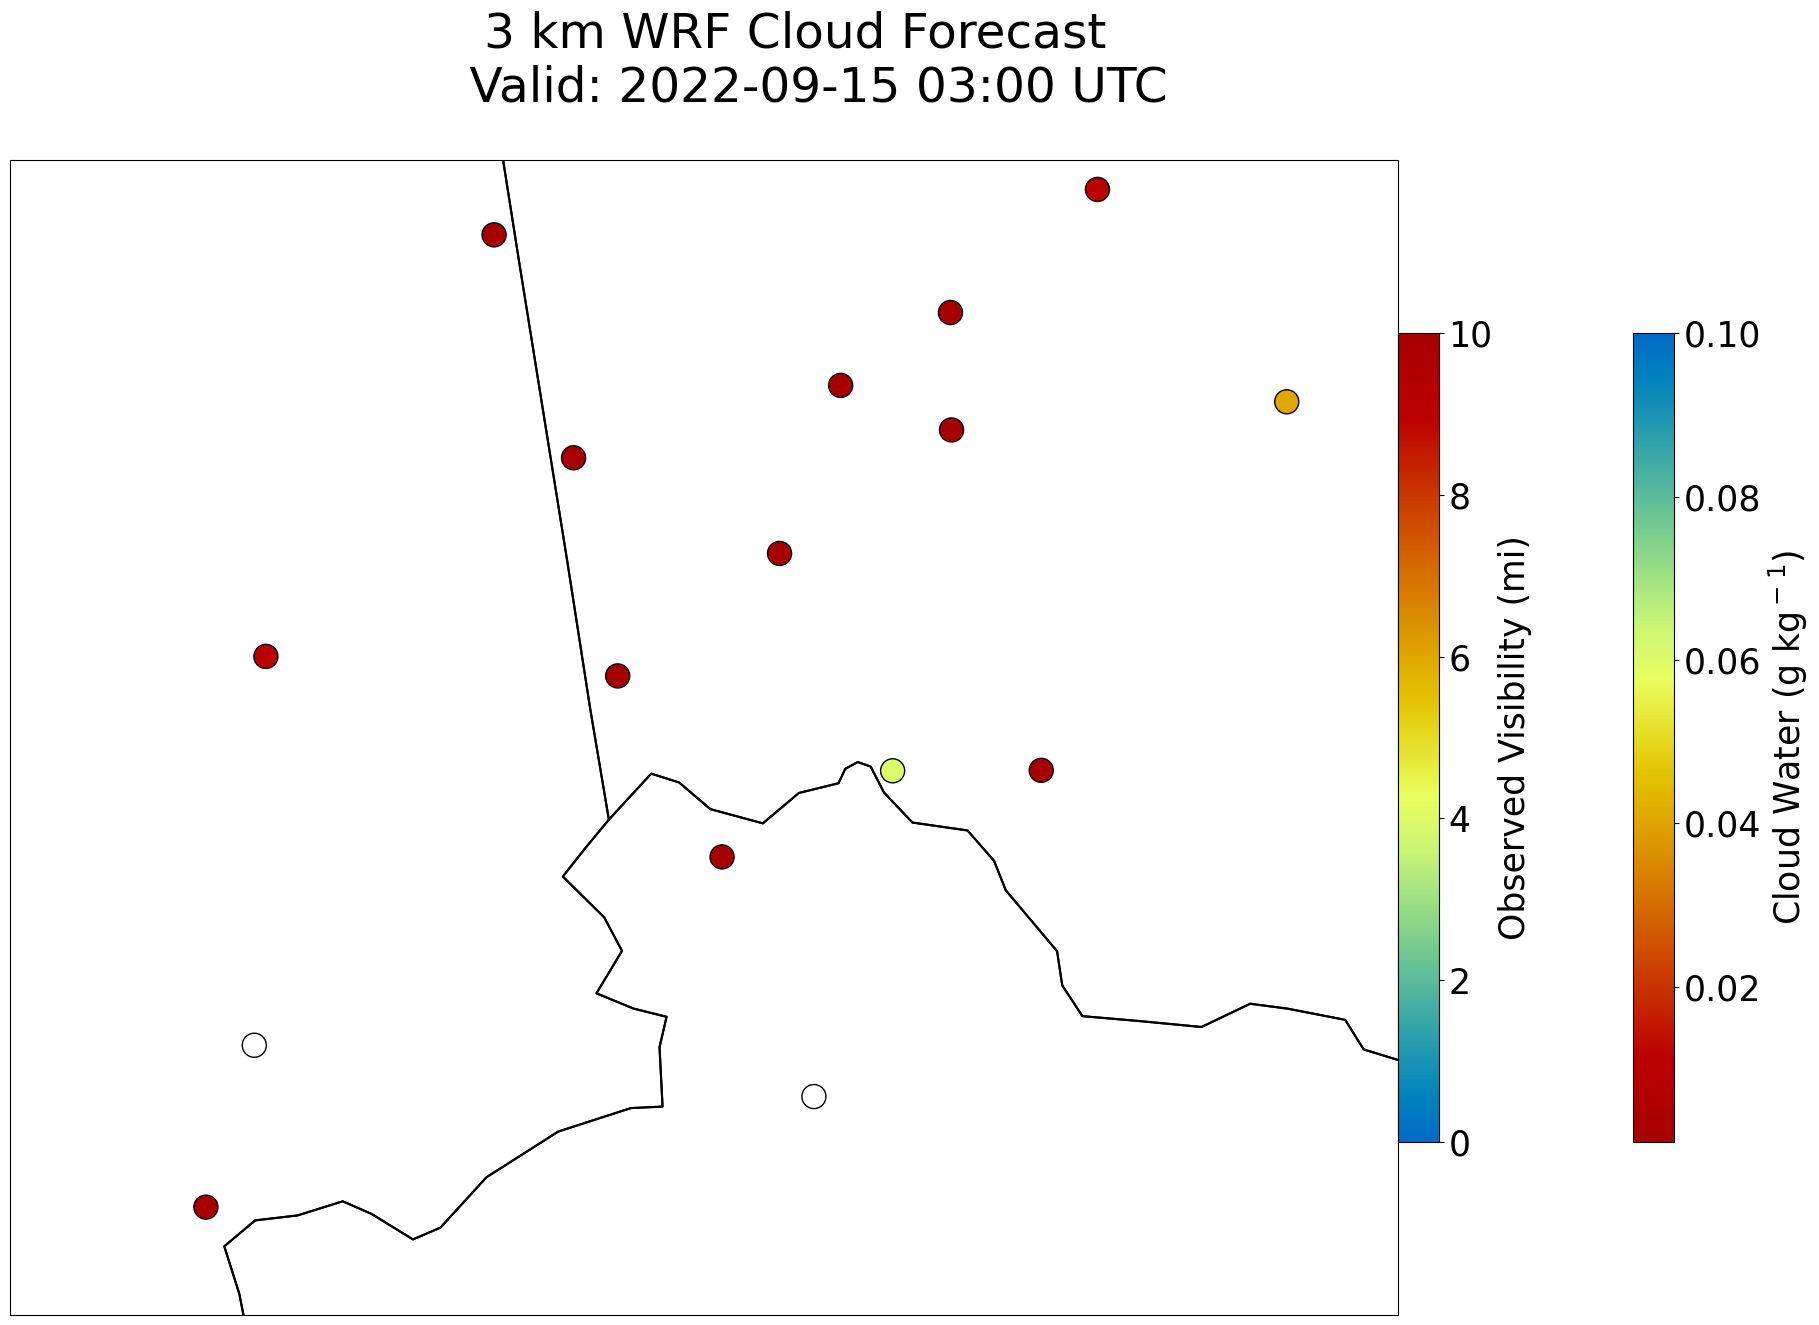

In [11]:
cenlon2 = cenlon1+0.2
cenlat2 = cenlat1+1.5

LL2 = (cenlon2-1.75,cenlat2+0.0,ccrs.PlateCarree())
UR2 = (cenlon2+0.,cenlat2+1.05,ccrs.PlateCarree())

figure_mosaic = """
D
"""

fig, axes = plt.subplot_mosaic(mosaic=figure_mosaic, figsize=(30,15), subplot_kw={'projection': crs})
prslev = [0,0.25,0.5,1.0,2.0,3.0,6.0]
#axes['D'].coastlines('50m',edgecolor='white',linewidth=0.75)
axes['D'].set_extent([LL2[0],UR2[0],LL2[1],UR2[1]])
axes['D'].add_feature(states,edgecolor='k',linewidth=1.5,zorder=4)
#axes['A'].add_feature(counties, edgecolor = 'black', linewidth = 0.5)
cloud1 = np.copy(np.asarray(cloud))*1000
cloud1[cloud1<0.001] = np.nan
#axes['C'].contour(ds4.longitude, ds4.latitude, pres/100,prslev,colors='k', linewidths=3, transform=ccrs.PlateCarree())
cb = axes['D'].pcolormesh(lon[0,:,:], lat[0,:,:], np.nanmax(cloud1[0,0:3,:,:],axis=0), cmap=pyart.graph.cm_colorblind.HomeyerRainbow_r, vmin=0.001, vmax=0.1, transform=ccrs.PlateCarree(),zorder=1)
cg = plt.colorbar(cb, ax = axes['D'], shrink = .7, pad = 0.06, fraction=0.046)
cg.ax.tick_params(labelsize=25)
cg.set_label("Cloud Water (g kg$^-$$^1$)",size = 25)
cn=axes['D'].scatter(Obs_lon, Obs_lat, c=Obs_V, s=300, cmap=pyart.graph.cm_colorblind.HomeyerRainbow, edgecolor='k', vmin=0, vmax=10, transform=ccrs.PlateCarree())
cb = plt.colorbar(cn, ax = axes['D'], shrink = .7, pad = 0.00,fraction=0.046)
cb.ax.tick_params(labelsize=25)
cb.set_label("Observed Visibility (mi)",size = 25)
#axes['D'].plot(poly_lon, poly_lat, linewidth=4, color='r', transform=ccrs.PlateCarree())
plt.suptitle('3 km WRF Cloud Forecast  \n Valid: '+dt.isoformat()[0:10]+' '+dt.isoformat()[11:16]+' UTC', size=35, x=.59)
#plt.savefig('100m_NRcomparison_NEWCASE.png', bbox_inches='tight')

Text(0.59, 0.98, '100 m Latent Heat Flux  \n Valid: 2022-09-15 03:00 UTC')

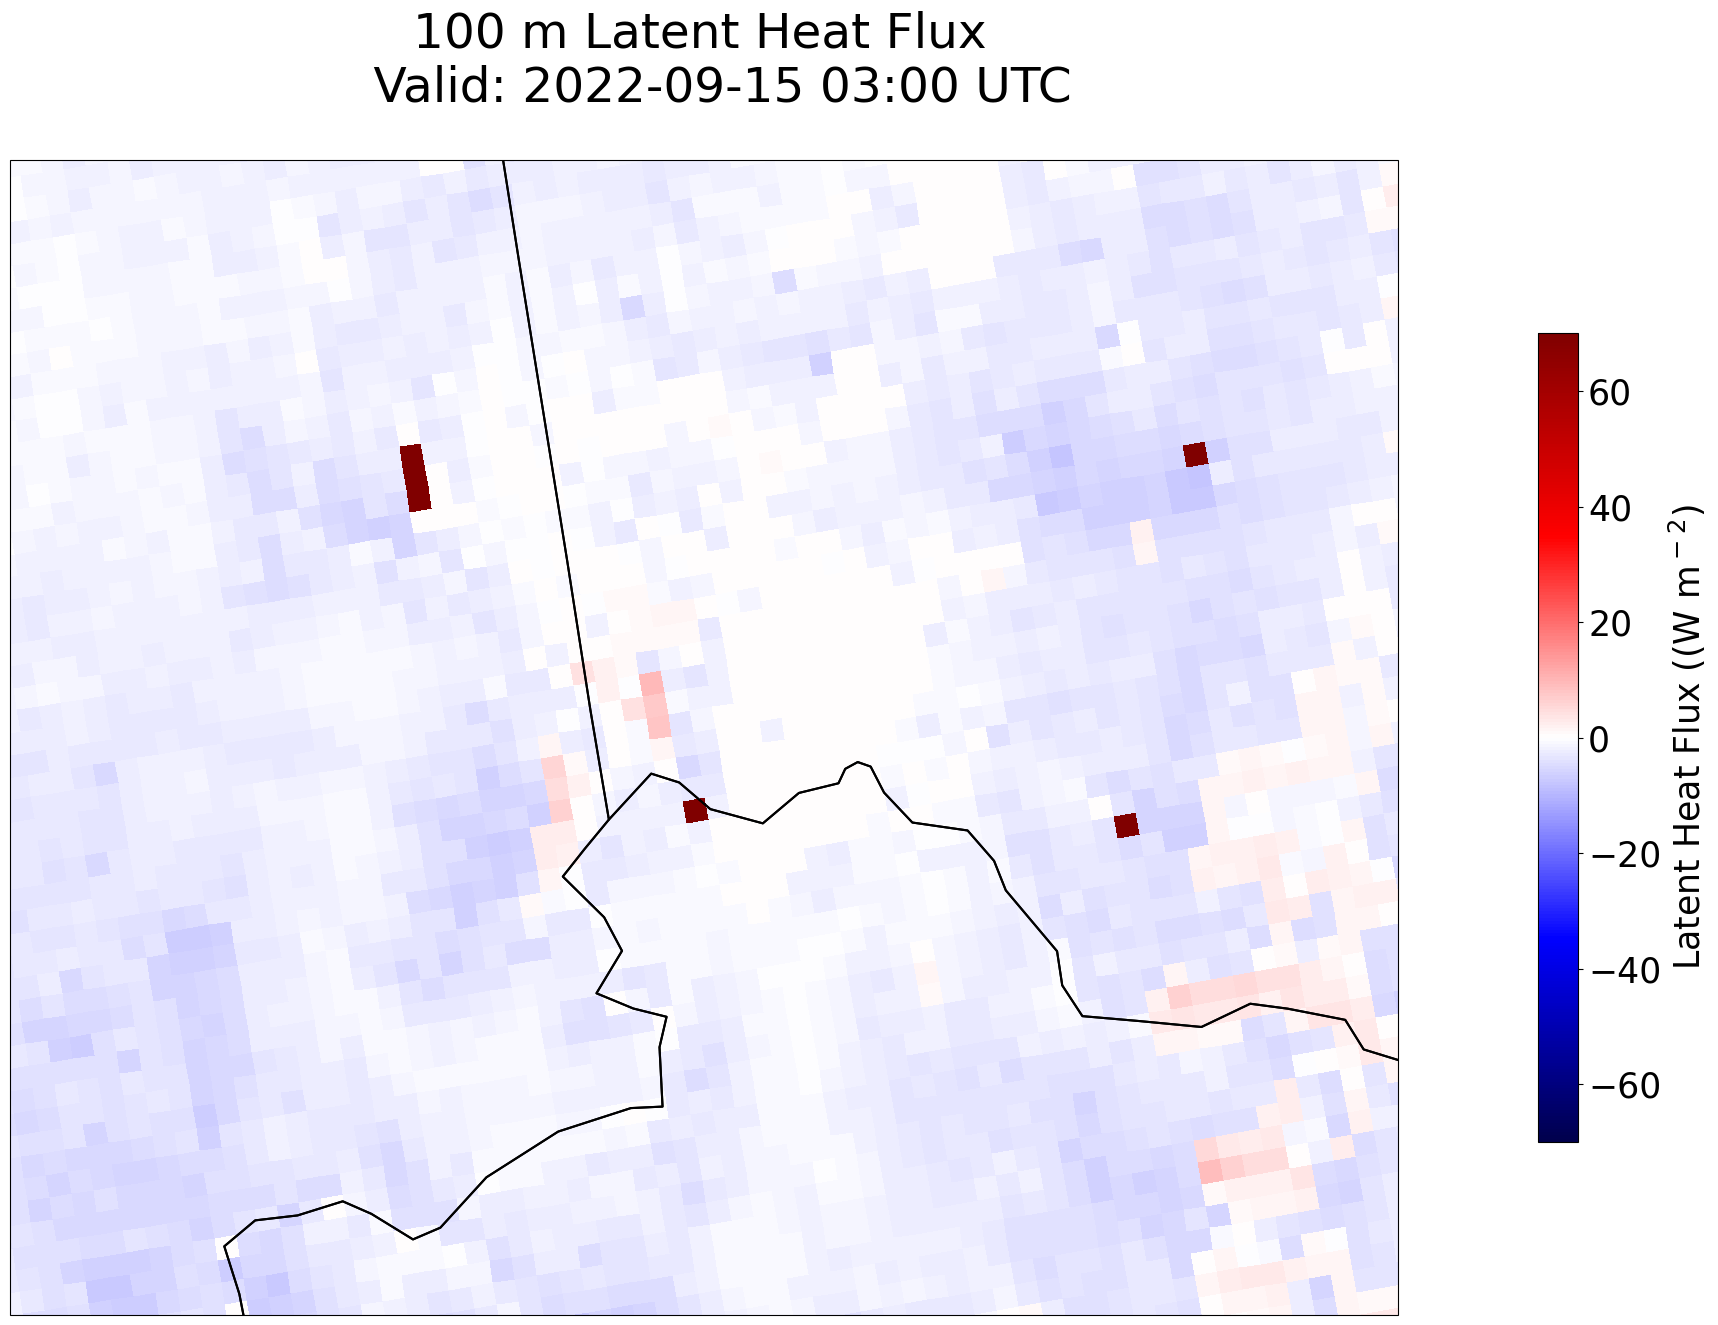

In [12]:
cenlon2 = cenlon1+0.2
cenlat2 = cenlat1+1.5

LL2 = (cenlon2-1.75,cenlat2+0.0,ccrs.PlateCarree())
UR2 = (cenlon2+0.,cenlat2+1.05,ccrs.PlateCarree())

figure_mosaic = """
D
"""

fig, axes = plt.subplot_mosaic(mosaic=figure_mosaic, figsize=(30,15), subplot_kw={'projection': crs})
prslev = [0,0.25,0.5,1.0,2.0,3.0,6.0]
#axes['D'].coastlines('50m',edgecolor='white',linewidth=0.75)
axes['D'].set_extent([LL2[0],UR2[0],LL2[1],UR2[1]])
axes['D'].add_feature(states,edgecolor='k',linewidth=1.5,zorder=4)
#axes['A'].add_feature(counties, edgecolor = 'black', linewidth = 0.5)
cloud1 = np.copy(np.asarray(cloud))*1000
cloud1[cloud1<0.001] = np.nan
#axes['C'].contour(ds4.longitude, ds4.latitude, pres/100,prslev,colors='k', linewidths=3, transform=ccrs.PlateCarree())
cb = axes['D'].pcolormesh(lon[0,:,:], lat[0,:,:], LH1[0,:,:], cmap=plt.cm.seismic, vmin=-70, vmax=70, transform=ccrs.PlateCarree(),zorder=1)
cg = plt.colorbar(cb, ax = axes['D'], shrink = .7, pad = 0.06, fraction=0.046)
cg.ax.tick_params(labelsize=25)
cg.set_label("Latent Heat Flux ((W m$^-$$^2$)",size = 25)
#cn=axes['D'].scatter(Obs_lon, Obs_lat, c=Obs_V, s=300, cmap=pyart.graph.cm_colorblind.HomeyerRainbow, edgecolor='k', vmin=0, vmax=10, transform=ccrs.PlateCarree())
#axes['D'].plot(poly_lon, poly_lat, linewidth=4, color='r', transform=ccrs.PlateCarree())
plt.suptitle('100 m Latent Heat Flux  \n Valid: '+dt.isoformat()[0:10]+' '+dt.isoformat()[11:16]+' UTC', size=35, x=.59)
#plt.savefig('100m_LHcomparison_NEWCASE.png', bbox_inches='tight')

Text(0.59, 0.98, '100 m Sensible Heat Flux  \n Valid: 2022-09-15 03:00 UTC')

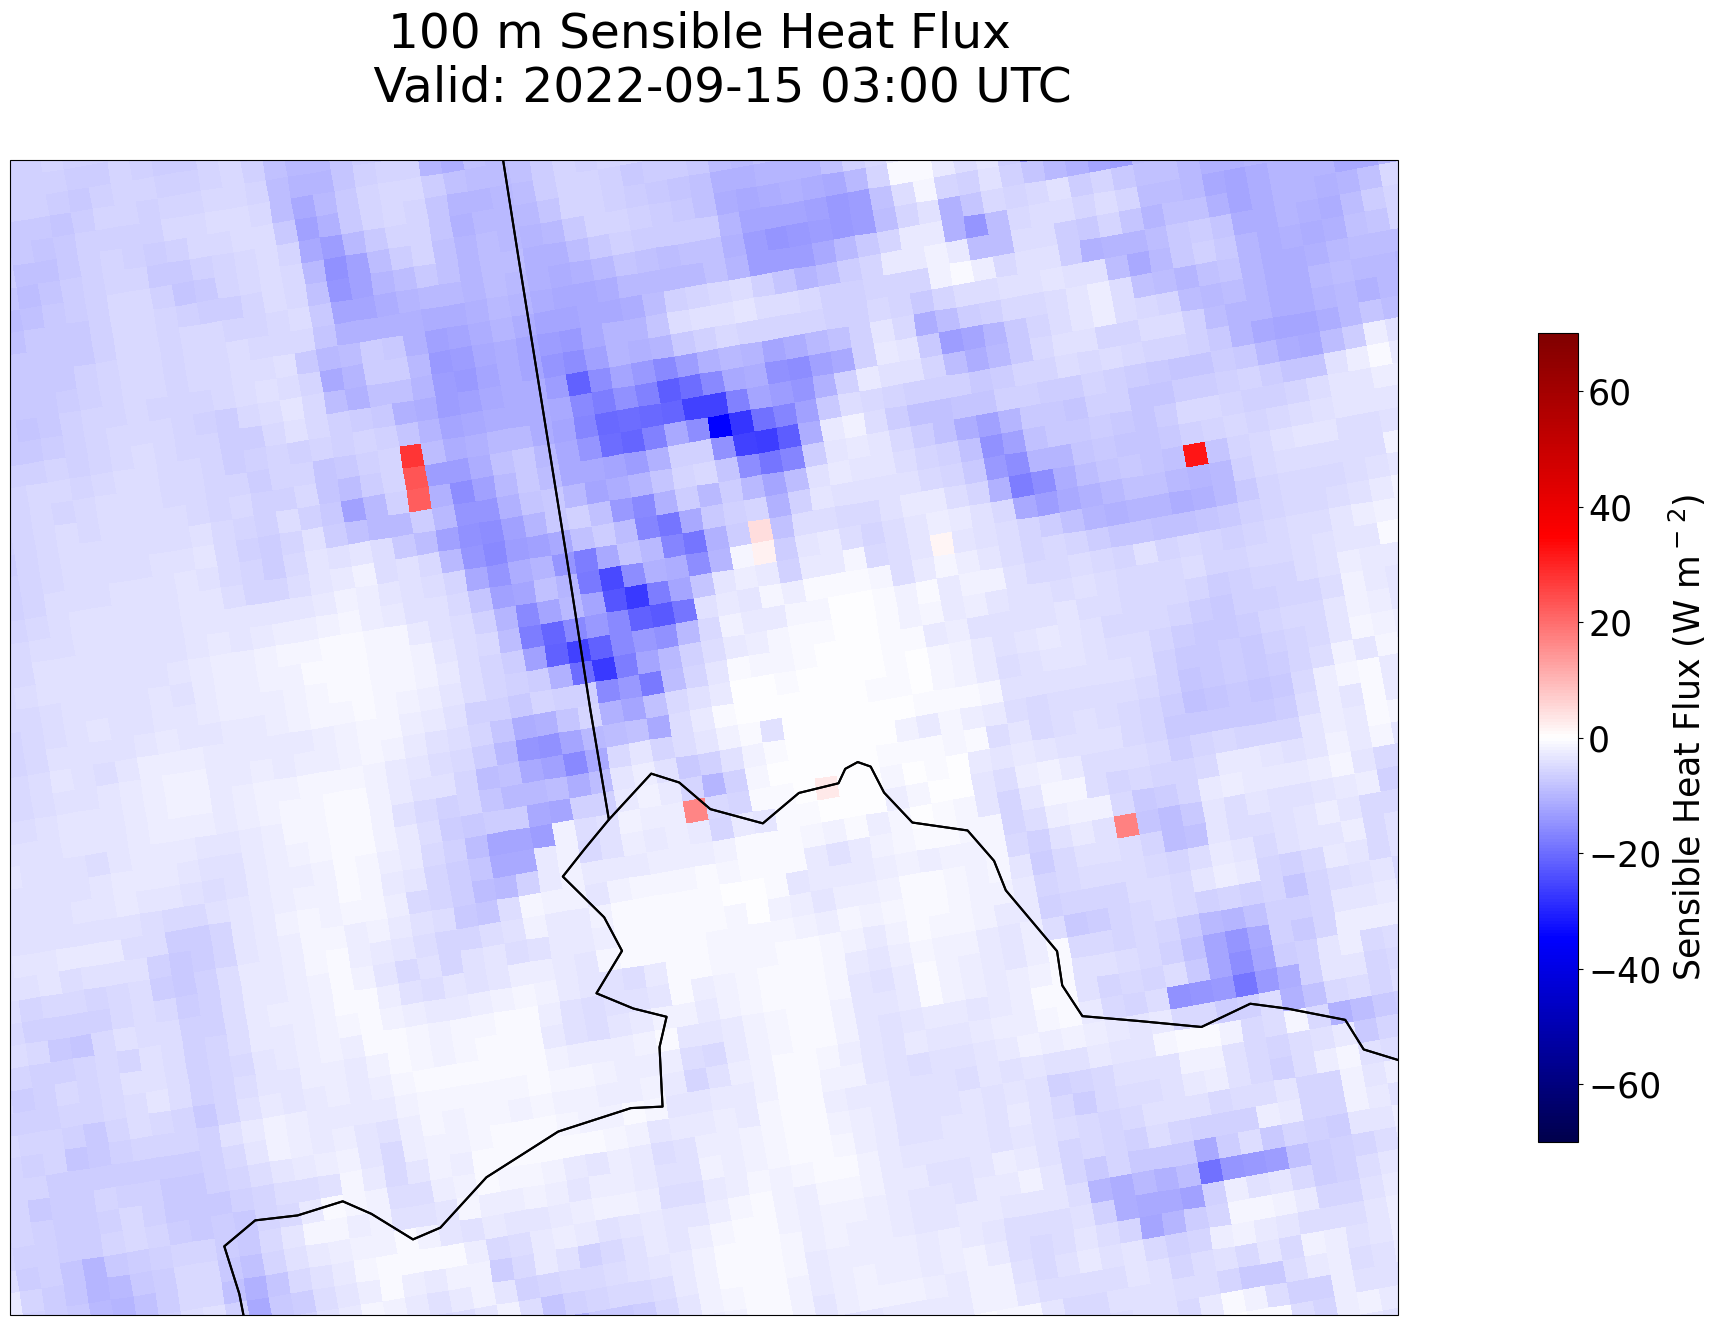

In [13]:
cenlon2 = cenlon1+0.2
cenlat2 = cenlat1+1.5

LL2 = (cenlon2-1.75,cenlat2+0.0,ccrs.PlateCarree())
UR2 = (cenlon2+0.,cenlat2+1.05,ccrs.PlateCarree())

figure_mosaic = """
D
"""

fig, axes = plt.subplot_mosaic(mosaic=figure_mosaic, figsize=(30,15), subplot_kw={'projection': crs})
prslev = [0,0.25,0.5,1.0,2.0,3.0,6.0]
#axes['D'].coastlines('50m',edgecolor='white',linewidth=0.75)
axes['D'].set_extent([LL2[0],UR2[0],LL2[1],UR2[1]])
axes['D'].add_feature(states,edgecolor='k',linewidth=1.5,zorder=4)
#axes['A'].add_feature(counties, edgecolor = 'black', linewidth = 0.5)
cloud1 = np.copy(np.asarray(cloud))*1000
cloud1[cloud1<0.001] = np.nan
#axes['C'].contour(ds4.longitude, ds4.latitude, pres/100,prslev,colors='k', linewidths=3, transform=ccrs.PlateCarree())
cb = axes['D'].pcolormesh(lon[0,:,:], lat[0,:,:], HF1[0,:,:], cmap=plt.cm.seismic, vmin=-70, vmax=70, transform=ccrs.PlateCarree(),zorder=1)
cg = plt.colorbar(cb, ax = axes['D'], shrink = .7, pad = 0.06, fraction=0.046)
cg.ax.tick_params(labelsize=25)
cg.set_label("Sensible Heat Flux (W m$^-$$^2$)",size = 25)
#cn=axes['D'].scatter(Obs_lon, Obs_lat, c=Obs_V, s=300, cmap=pyart.graph.cm_colorblind.HomeyerRainbow, edgecolor='k', vmin=0, vmax=10, transform=ccrs.PlateCarree())
#axes['D'].plot(poly_lon, poly_lat, linewidth=4, color='r', transform=ccrs.PlateCarree())
plt.suptitle('100 m Sensible Heat Flux  \n Valid: '+dt.isoformat()[0:10]+' '+dt.isoformat()[11:16]+' UTC', size=35, x=.59)
#plt.savefig('100m_HFXcomparison_NEWCASE.png', bbox_inches='tight')

In [14]:
dt = datetime(2022,9,15,3)
#Make a plot with all three 2m temperature outputs on it
wrfoutb = Dataset('/glade/derecho/scratch/mawilson/20210604_newcase/nature_100IOP6/final_nature/wrfout_d01_2022-'+str(dt.isoformat()[5:7])+'-'+str(dt.isoformat()[8:10])+'_'+str(dt.isoformat()[11:13])+':00:00')
#wrfoutb = Dataset('/glade/campaign/ral/aap/mawilson/fog_ens_1km/fc_40IOP6NEW/2022091500.e001/wrfout_d01_2022-'+str(dt.isoformat()[5:7])+'-'+str(dt.isoformat()[8:10])+'_'+str(dt.isoformat()[11:13])+':00:00')

lonb = wrfoutb.variables['XLONG']
latb = wrfoutb.variables['XLAT']
U10b = wrfoutb.variables['U10']
V10b = wrfoutb.variables['U10']
T2b = np.asarray(wrfoutb.variables['T2'])*units('K')
T2Fb = T2b .to('degF')
Q2b = np.asarray(wrfoutb.variables['Q2'])
P2b = np.asarray(wrfoutb.variables['PSFC'][:]/100) * units('hPa')
Td2b = dewpoint_from_specific_humidity(P2b[0,:,:], T2b[0,:,:], Q2b[0,:,:]*units('kg/kg'))
RH2b = relative_humidity_from_specific_humidity(P2b[0,:,:], T2b[0,:,:], Q2b[0,:,:]*units('kg/kg'))
SPD10b = wind_speed(np.asarray(U10b)*units('m/s'), np.asarray(V10b)*units('m/s'))
cloudb=wrfoutb.variables['QCLOUD']


In [15]:
hour_t = 3
hour_s = '03'

#Load in WRF data from both runs
def read_mpas(exper):
    #wrfout = Dataset('/glade/derecho/scratch/mawilson/20210604_newcase/'+exper+'/wrfout_d01_2022-'+str(dt.isoformat()[5:7])+'-'+str(dt.isoformat()[8:10])+'_'+str(dt.isoformat()[11:13])+':00:00')
    #wrfout = Dataset('/glade/derecho/scratch/mawilson/20210604_newcase/'+exper+str(dt.isoformat()[5:7])+'-'+str(dt.isoformat()[8:10])+'_'+str(dt.isoformat()[11:13])+':00:00')

    wrfout = Dataset(exper)
    #wrfout = Dataset('/glade/derecho/scratch/mawilson/mpas_tests/ohio_mesh/'+exper+'/gridded_2021-'+str(dt.isoformat()[5:7])+'-'+str(dt.isoformat()[8:10])+'_'+str(dt.isoformat()[11:13])+'.nc')

    
    #wrfout = Dataset('/glade/derecho/scratch/mawilson/20210604_newcase/'+exper+'/wrfout_d02_2022-'+str(dt.isoformat()[5:7])+'-'+str(dt.isoformat()[8:10])+'_'+str(dt.isoformat()[11:13])+':00:00')
    #wrfout = Dataset('/glade/derecho/scratch/mawilson/20210604_newcase/'+exper+'/wrfout_d02_2021-'+str(dt.isoformat()[5:7])+'-'+str(dt.isoformat()[8:10])+'_'+str(dt.isoformat()[11:13])+':00:00')
    
    lon = wrfout.variables['longitude']
    lat = wrfout.variables['latitude']
    U10 = wrfout.variables['u10'][:]
    V10 = wrfout.variables['v10'][:]
    T2 = np.asarray(wrfout.variables['t2m'][:])*units('K')
    T2F = T2 .to('degF')
    Q2 = np.asarray(wrfout.variables['q2'][:])
    P2 = np.asarray(wrfout.variables['surface_pressure'][:]/100) * units('hPa')
    Td2 = dewpoint_from_specific_humidity(P2[0,:,:], T2[0,:,:], Q2[0,:,:]*units('kg/kg'))
    RH2 = relative_humidity_from_specific_humidity(P2[0,:,:], T2[0,:,:], Q2[0,:,:]*units('kg/kg'))
    SPD10 = wind_speed(np.asarray(U10)*units('m/s'), np.asarray(V10)*units('m/s'))
    cloud=wrfout.variables['qc']
    u = wrfout.variables['uReconstructZonal'][:]
    v = wrfout.variables['uReconstructMeridional'][:]
    th = wrfout.variables['theta'][:]
    th2 = np.asarray(th[:,0,:,:])*units('K')
    th2F = th2.to('degF')
    relhum3 = wrfout.variables['relhum'][:]
    p_b = wrfout.variables['pressure_base'][:]
    p_p = wrfout.variables['pressure_p'][:]
    p_full = p_b + p_p
    t3 = temperature_from_potential_temperature(np.asarray(p_full[:,:,:,:])*units('Pa'), np.asarray(th[:,:,:,:])*units('K'))
    t31 = t3.to('degF')
    t23 = t31[:,0,:,:]

    #return lon, lat, cloud, RH2, T2F, SPD10, u, v, th, relhum3, p_full
    return lon, lat, cloud, RH2, T2F, SPD10, t31, relhum3, p_full
mem=30
all_RH = np.zeros((mem, 276, 240))
for member in np.arange(1,mem+1,1):
    #lonm, latm, cloudm, RH2m, T2m, SPD10m = read_mpas('test_0719')
    #lonm, latm, cloudm, RH2m, T2m, SPD10m, th3, rh3, p3 = read_mpas('/glade/derecho/scratch/mawilson/mpas_OSSE/MPAS-DART/rundir2/member'+str(member)+'/regrid_2022-09-15_'+hour_s+'.nc')
    lonm, latm, cloudm, RH2m, T2m, SPD10m, th3, rh3, p3 = read_mpas('/glade/campaign/ral/aap/mawilson/OSSEs/NODA/member'+str(member)+'/regrid_2022-09-15_'+hour_s+'.nc')
    #lonm, latm, cloudm, RH2m, T2m, SPD10m, u3, v3, th3, rh3, p3 = read_mpas('/glade/derecho/scratch/mawilson/mpas_OSSE/MPAS-DART/regridded_output/CNTRL_test/member'+str(member)+'/regrid_2022-09-15_'+hour_s+'.nc')
    #lonm, latm, cloudm, RH2m, T2m, SPD10m = read_mpas('test_0604')

    #all_RH[member-1,:,:]=th3[0,0,:,:]
    all_RH[member-1,:,:]=T2m

In [16]:
all_RH_m = np.mean(all_RH, axis=0)

plotted
A
plotted
B
plotted
C


Text(0.5, 0.8, '03 UTC 2m Temperature')

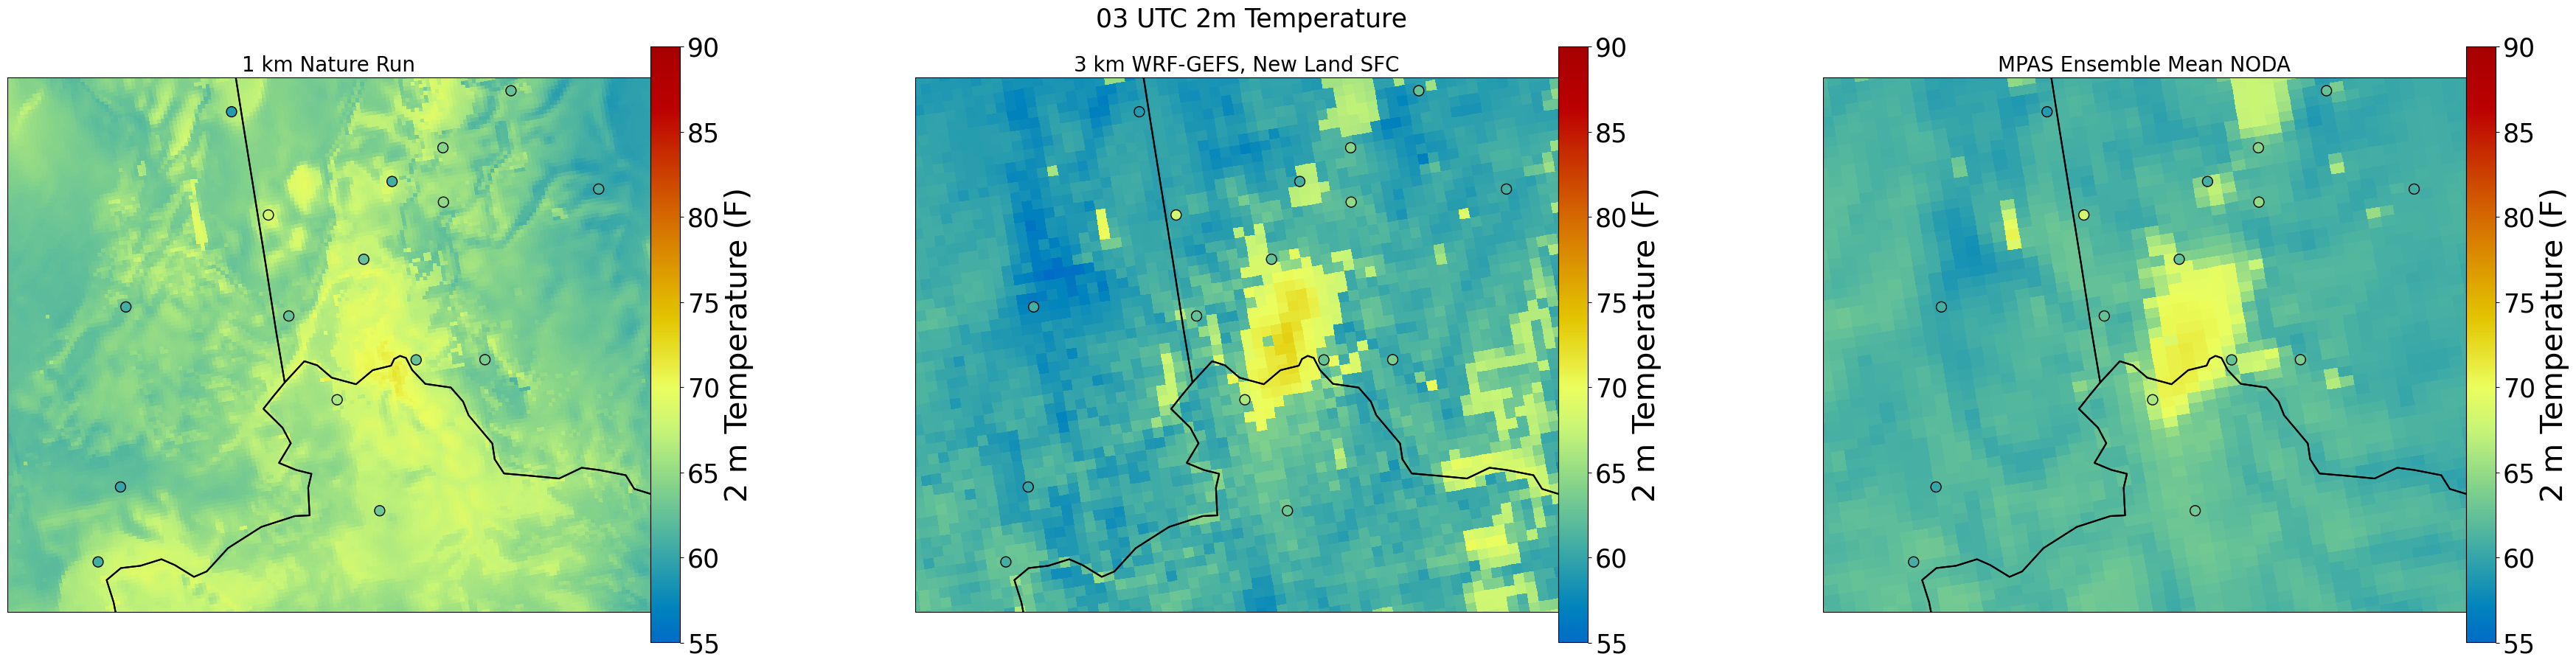

In [17]:
cenlon2 = cenlon1+0.2
cenlat2 = cenlat1+1.5

LL2 = (cenlon2-1.75,cenlat2+0.0,ccrs.PlateCarree())
UR2 = (cenlon2+0.,cenlat2+1.05,ccrs.PlateCarree())

figure_mosaic = """
ABC
"""

fig, axes = plt.subplot_mosaic(mosaic=figure_mosaic, figsize=(45,15), subplot_kw={'projection': crs})

plt.sca(ax=axes['A'])
axes['A'].set_extent([LL2[0],UR2[0],LL2[1],UR2[1]])
axes['A'].add_feature(states,edgecolor='black',linewidth=1.5)
#axes['A'].add_feature(counties, edgecolor = 'black', linewidth = 0.5)
cf = axes['A'].pcolormesh(lonb[0,:,:], latb[0,:,:], T2Fb[0,:,:], cmap=pyart.graph.cm_colorblind.HomeyerRainbow, vmin=55, vmax=90, transform=ccrs.PlateCarree())
print('plotted')
cg = plt.colorbar(cf, ax = axes['A'], shrink = .7, pad = 0)
cg.ax.tick_params(labelsize=25)
cg.set_label("2 m Temperature (F)",size = 30)
axes['A'].scatter(Obs_lon, Obs_lat, c=Obs_Ti, edgecolors='k', s=100, vmin=55, vmax=90, cmap=pyart.graph.cm_colorblind.HomeyerRainbow, transform=ccrs.PlateCarree())
print('A')
plt.title('1 km Nature Run', size=20)

plt.sca(ax=axes['B'])
axes['B'].set_extent([LL2[0],UR2[0],LL2[1],UR2[1]])
axes['B'].add_feature(states,edgecolor='black',linewidth=1.5)
#axes['A'].add_feature(counties, edgecolor = 'black', linewidth = 0.5)
cf = axes['B'].pcolormesh(lon[0,:,:], lat[0,:,:], T2F[0,:,:], cmap=pyart.graph.cm_colorblind.HomeyerRainbow, vmin=55, vmax=90, transform=ccrs.PlateCarree())
print('plotted')
cg = plt.colorbar(cf, ax = axes['B'], shrink = .7, pad = 0)
cg.ax.tick_params(labelsize=25)
cg.set_label("2 m Temperature (F)",size = 30)
axes['B'].scatter(Obs_lon, Obs_lat, c=Obs_Ti, edgecolors='k', s=100, vmin=55, vmax=90, cmap=pyart.graph.cm_colorblind.HomeyerRainbow, transform=ccrs.PlateCarree())
print('B')
plt.title('3 km WRF-GEFS, New Land SFC', size=20)

plt.sca(ax=axes['C'])
axes['C'].set_extent([LL2[0],UR2[0],LL2[1],UR2[1]])
axes['C'].add_feature(states,edgecolor='black',linewidth=1.5)
#axes['A'].add_feature(counties, edgecolor = 'black', linewidth = 0.5)
cf = axes['C'].pcolormesh(lonm, latm, all_RH_m, cmap=pyart.graph.cm_colorblind.HomeyerRainbow, vmin=55, vmax=90, transform=ccrs.PlateCarree())
print('plotted')
cg = plt.colorbar(cf, ax = axes['C'], shrink = .7, pad = 0)
cg.ax.tick_params(labelsize=25)
cg.set_label("2 m Temperature (F)",size = 30)
axes['C'].scatter(Obs_lon, Obs_lat, c=Obs_Ti, edgecolors='k', s=100, vmin=55, vmax=90, cmap=pyart.graph.cm_colorblind.HomeyerRainbow, transform=ccrs.PlateCarree())
print('C')
plt.title('MPAS Ensemble Mean NODA', size=20)

plt.suptitle(hour_s+' UTC 2m Temperature', size=25, y=0.80)
#plt.savefig(hour_s+'WRFMPASbiascomp.png', bbox_inches='tight')

In [23]:
#See if the issue is WRF soil temperature?
TSLB_B = np.asarray(wrfoutb.variables['TSLB'][:])*units('K')
TSLB = np.asarray(wrfout.variables['TSLB'][:])*units('K')

print(TSLB_B.shape)
print(np.mean(TSLB[0,:,:]))
print(np.mean(TSLB_B[0,:,:]))

(1, 4, 720, 828)
289.12103271484375 kelvin
291.3549499511719 kelvin


plotted
A
plotted
B


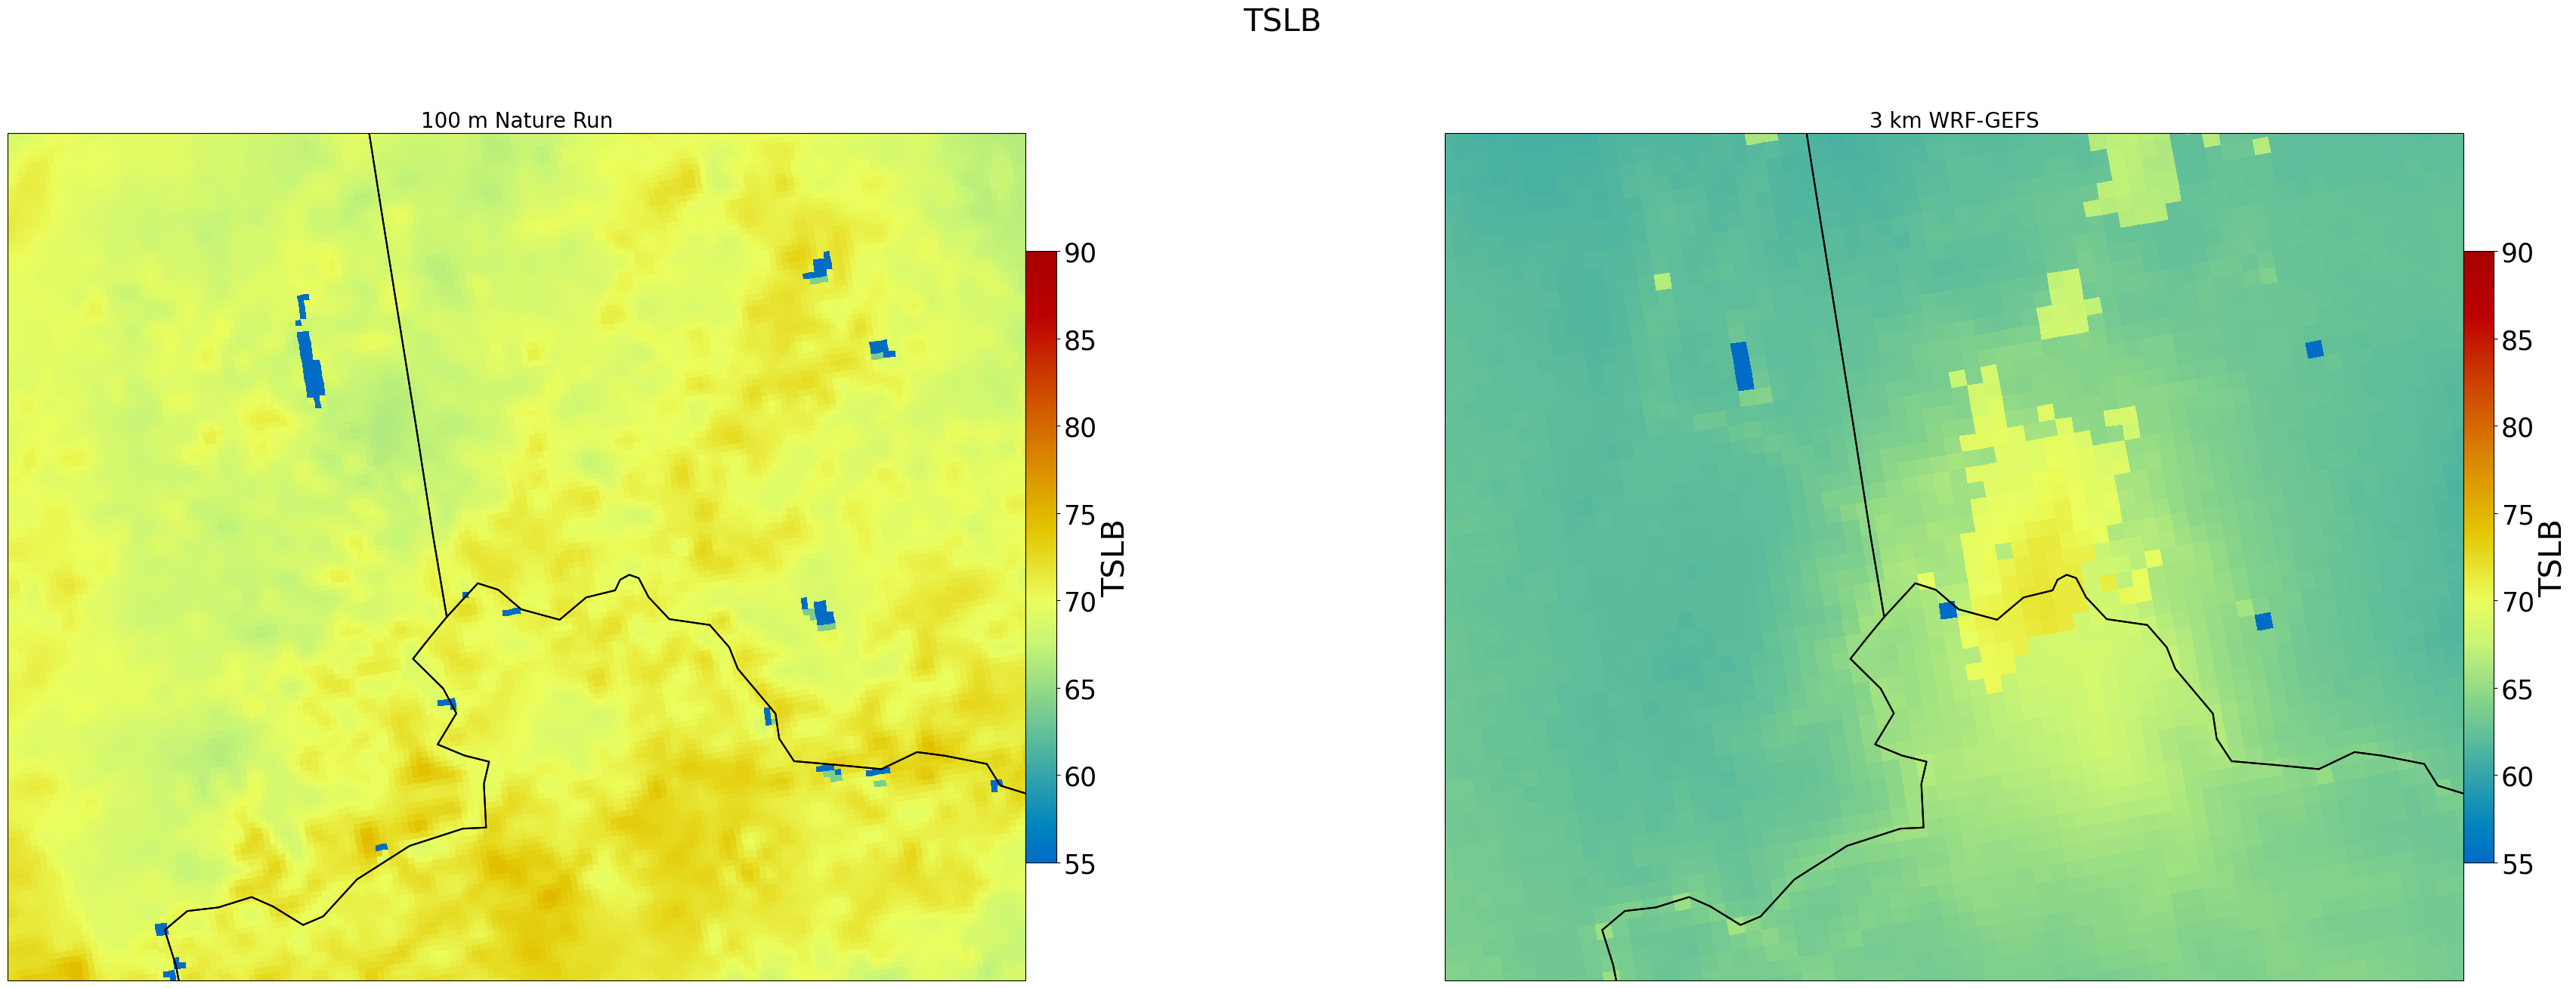

In [27]:
level_dirt=3

cenlon2 = cenlon1+0.2
cenlat2 = cenlat1+1.5

LL2 = (cenlon2-1.75,cenlat2+0.0,ccrs.PlateCarree())
UR2 = (cenlon2+0.,cenlat2+1.05,ccrs.PlateCarree())

figure_mosaic = """
AB
"""

fig, axes = plt.subplot_mosaic(mosaic=figure_mosaic, figsize=(45,15), subplot_kw={'projection': crs})

plt.sca(ax=axes['A'])
axes['A'].set_extent([LL2[0],UR2[0],LL2[1],UR2[1]])
axes['A'].add_feature(states,edgecolor='black',linewidth=1.5)
#axes['A'].add_feature(counties, edgecolor = 'black', linewidth = 0.5)
cf = axes['A'].pcolormesh(lonb[0,:,:], latb[0,:,:], (np.asarray(TSLB_B[0,1,:,:].to('degF'))), vmin=55, vmax=90, cmap=pyart.graph.cm_colorblind.HomeyerRainbow, transform=ccrs.PlateCarree())
print('plotted')
cg = plt.colorbar(cf, ax = axes['A'], shrink = .7, pad = 0)
cg.ax.tick_params(labelsize=25)
cg.set_label("TSLB",size = 30)
#axes['A'].scatter(Obs_lon, Obs_lat, c=Obs_Ti, edgecolors='k', s=100, vmin=55, vmax=90, cmap=pyart.graph.cm_colorblind.HomeyerRainbow, transform=ccrs.PlateCarree())
print('A')
plt.title('100 m Nature Run', size=20)

plt.sca(ax=axes['B'])
axes['B'].set_extent([LL2[0],UR2[0],LL2[1],UR2[1]])
axes['B'].add_feature(states,edgecolor='black',linewidth=1.5)
#axes['A'].add_feature(counties, edgecolor = 'black', linewidth = 0.5)
cf = axes['B'].pcolormesh(lon[0,:,:], lat[0,:,:], (np.asarray(TSLB[0,1,:,:].to('degF'))), vmin=55, vmax=90, cmap=pyart.graph.cm_colorblind.HomeyerRainbow, transform=ccrs.PlateCarree())
print('plotted')
cg = plt.colorbar(cf, ax = axes['B'], shrink = .7, pad = 0)
cg.ax.tick_params(labelsize=25)
cg.set_label("TSLB",size = 30)
#axes['B'].scatter(Obs_lon, Obs_lat, c=Obs_Ti, edgecolors='k', s=100, vmin=55, vmax=90, cmap=pyart.graph.cm_colorblind.HomeyerRainbow, transform=ccrs.PlateCarree())
print('B')
plt.title('3 km WRF-GEFS', size=20)

plt.suptitle('TSLB', size=30)

plt.savefig('TS_TSLB1.png', bbox_inches='tight')

In [ ]:
level_dirt=2

cenlon2 = cenlon1+0.2
cenlat2 = cenlat1+1.5

LL2 = (cenlon2-1.75,cenlat2+0.0,ccrs.PlateCarree())
UR2 = (cenlon2+0.,cenlat2+1.05,ccrs.PlateCarree())

figure_mosaic = """
AB
"""

fig, axes = plt.subplot_mosaic(mosaic=figure_mosaic, figsize=(45,15), subplot_kw={'projection': crs})

plt.sca(ax=axes['A'])
axes['A'].set_extent([LL2[0],UR2[0],LL2[1],UR2[1]])
axes['A'].add_feature(states,edgecolor='black',linewidth=1.5)
#axes['A'].add_feature(counties, edgecolor = 'black', linewidth = 0.5)
cf = axes['A'].pcolormesh(lonb[0,:,:], latb[0,:,:], (np.asarray(TSLB_B[0,level_dirt,:,:])*units('K')).to('degF'), cmap=pyart.graph.cm_colorblind.HomeyerRainbow, vmin=55, vmax=90, transform=ccrs.PlateCarree())
print('plotted')
cg = plt.colorbar(cf, ax = axes['A'], shrink = .7, pad = 0)
cg.ax.tick_params(labelsize=25)
cg.set_label("Soil Temperature (F)",size = 30)
axes['A'].scatter(Obs_lon, Obs_lat, c=Obs_Ti, edgecolors='k', s=100, vmin=55, vmax=90, cmap=pyart.graph.cm_colorblind.HomeyerRainbow, transform=ccrs.PlateCarree())
print('A')
plt.title('1 km Nature Run', size=20)

plt.sca(ax=axes['B'])
axes['B'].set_extent([LL2[0],UR2[0],LL2[1],UR2[1]])
axes['B'].add_feature(states,edgecolor='black',linewidth=1.5)
#axes['A'].add_feature(counties, edgecolor = 'black', linewidth = 0.5)
cf = axes['B'].pcolormesh(lon[0,:,:], lat[0,:,:], (np.asarray(TSLB[0,level_dirt,:,:])*units('K')).to('degF'), cmap=pyart.graph.cm_colorblind.HomeyerRainbow, vmin=55, vmax=90, transform=ccrs.PlateCarree())
print('plotted')
cg = plt.colorbar(cf, ax = axes['B'], shrink = .7, pad = 0)
cg.ax.tick_params(labelsize=25)
cg.set_label("Soil Temperature (F)",size = 30)
axes['B'].scatter(Obs_lon, Obs_lat, c=Obs_Ti, edgecolors='k', s=100, vmin=55, vmax=90, cmap=pyart.graph.cm_colorblind.HomeyerRainbow, transform=ccrs.PlateCarree())
print('B')
plt.title('3 km WRF-GEFS, New Land SFC', size=20)

plt.suptitle('Soil Temperatures, Level '+str(level_dirt), size=30)

#plt.savefig('SoilTempComp'+str(level_dirt)+'.png', bbox_inches='tight')

In [ ]:
level_dirt=3

cenlon2 = cenlon1+0.2
cenlat2 = cenlat1+1.5

LL2 = (cenlon2-8,cenlat2-8,ccrs.PlateCarree())
UR2 = (cenlon2+8.,cenlat2+8,ccrs.PlateCarree())

figure_mosaic = """
AB
"""

fig, axes = plt.subplot_mosaic(mosaic=figure_mosaic, figsize=(45,15), subplot_kw={'projection': crs})

plt.sca(ax=axes['A'])
axes['A'].set_extent([LL2[0],UR2[0],LL2[1],UR2[1]])
axes['A'].add_feature(states,edgecolor='black',linewidth=1.5)
#axes['A'].add_feature(counties, edgecolor = 'black', linewidth = 0.5)
cf = axes['A'].pcolormesh(lonb[0,:,:], latb[0,:,:], (np.asarray(TSLB_B[0,level_dirt,:,:])*units('K')).to('degF'), cmap=pyart.graph.cm_colorblind.HomeyerRainbow, vmin=55, vmax=90, transform=ccrs.PlateCarree())
print('plotted')
cg = plt.colorbar(cf, ax = axes['A'], shrink = .7, pad = 0)
cg.ax.tick_params(labelsize=25)
cg.set_label("Soil Temperature (F)",size = 30)
axes['A'].scatter(Obs_lon, Obs_lat, c=Obs_Ti, edgecolors='k', s=100, vmin=55, vmax=90, cmap=pyart.graph.cm_colorblind.HomeyerRainbow, transform=ccrs.PlateCarree())
print('A')
plt.title('1 km Nature Run', size=20)

plt.sca(ax=axes['B'])
axes['B'].set_extent([LL2[0],UR2[0],LL2[1],UR2[1]])
axes['B'].add_feature(states,edgecolor='black',linewidth=1.5)
#axes['A'].add_feature(counties, edgecolor = 'black', linewidth = 0.5)
cf = axes['B'].pcolormesh(lon[0,:,:], lat[0,:,:], (np.asarray(TSLB[0,level_dirt,:,:])*units('K')).to('degF'), cmap=pyart.graph.cm_colorblind.HomeyerRainbow, vmin=55, vmax=90, transform=ccrs.PlateCarree())
print('plotted')
cg = plt.colorbar(cf, ax = axes['B'], shrink = .7, pad = 0)
cg.ax.tick_params(labelsize=25)
cg.set_label("Soil Temperature (F)",size = 30)
axes['B'].scatter(Obs_lon, Obs_lat, c=Obs_Ti, edgecolors='k', s=100, vmin=55, vmax=90, cmap=pyart.graph.cm_colorblind.HomeyerRainbow, transform=ccrs.PlateCarree())
print('B')
plt.title('3 km WRF-GEFS, New Land SFC', size=20)

plt.suptitle('Soil Temperatures, Level '+str(level_dirt), size=30)

#plt.savefig('SoilTempComp'+str(level_dirt)+'.png', bbox_inches='tight')

In [ ]:
wrf_2 = Dataset('/glade/derecho/scratch/mawilson/OSSE_WRF/ic_wrf/wrfinput_d01')

In [ ]:
print(wrfoutb.variables['LANDUSEF'])